In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
from   matplotlib import pyplot as plt

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'SRF gun simulation',
        '--data_dir', '../../data/delay',
        '--data_file', 'gun_sim',
        '--data_nsample', '200',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '64',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '24',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"data": 10}',
    ]
)

In [3]:
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model = kind.model(args)

In [5]:
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=0.307720, valid=0.149161, test=0.132241
	validation loss decreased (inf -> 0.149161), saving model ...
	epoch 2 losses: train=0.196661, valid=0.132093, test=0.117446
	validation loss decreased (0.149161 -> 0.132093), saving model ...
	epoch 3 losses: train=0.148927, valid=0.124167, test=0.109690
	validation loss decreased (0.132093 -> 0.124167), saving model ...
	epoch 4 losses: train=0.079400, valid=0.032985, test=0.028615
	validation loss decreased (0.124167 -> 0.032985), saving model ...
	epoch 5 losses: train=0.017490, valid=0.016168, test=0.013961
	validation loss decreased (0.032985 -> 0.016168), saving model ...
	epoch 6 losses: train=0.014454, valid=0.014972, test=0.012791
	validation loss decreased (0.016168 -> 0.014972), saving model ...
	epoch 7 losses: train=0.013476, valid=0.014439, test=0.012228
	validation loss decreased (0.014972 -> 0.014439), saving model ...
	epoch 8 losses: train=0.013025, valid=0.012032, test=0.01

In [6]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

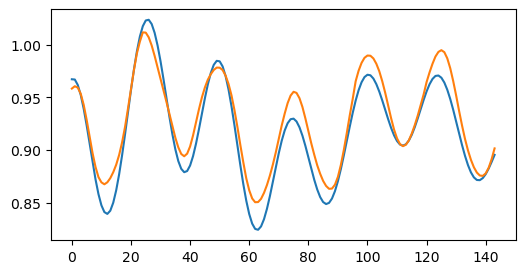

In [7]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

In [8]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=-0.040644, valid=-0.199862, test=-0.213710
	validation loss decreased (inf -> -0.199862), saving model ...
	epoch 2 losses: train=-0.533401, valid=-0.376485, test=-0.411483
	validation loss decreased (-0.199862 -> -0.376485), saving model ...
	epoch 3 losses: train=-0.637968, valid=-0.435007, test=-0.464406
	validation loss decreased (-0.376485 -> -0.435007), saving model ...
	epoch 4 losses: train=-0.692498, valid=-0.560194, test=-0.582048
	validation loss decreased (-0.435007 -> -0.560194), saving model ...
	epoch 5 losses: train=-0.755043, valid=-0.607302, test=-0.622453
	validation loss decreased (-0.560194 -> -0.607302), saving model ...
	epoch 6 losses: train=-0.771625, valid=-0.587421, test=-0.607613
	early stopping counter: 1 out of 10
	epoch 7 losses: train=-0.824218, valid=-0.638723, test=-0.670745
	validation loss decreased (-0.607302 -> -0.638723), saving model ...
	epoch 8 losses: train=-0.842226, valid=-0.656438,

In [9]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

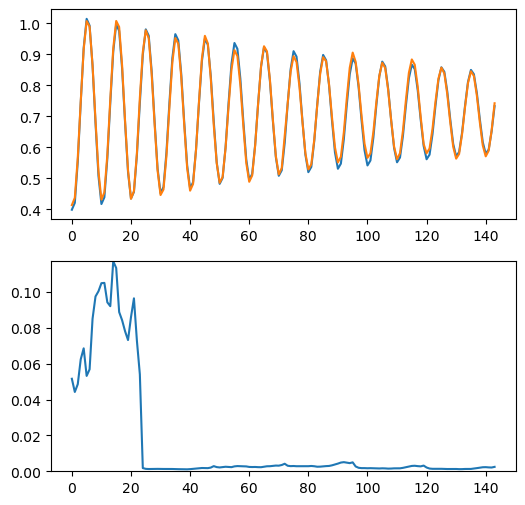

In [10]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

In [11]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient mean >>>
	epoch 1 losses: train=0.211768, valid=0.125397, test=0.122996
	validation loss decreased (inf -> 0.125397), saving model ...
	epoch 2 losses: train=0.091251, valid=0.111686, test=0.108803
	validation loss decreased (0.125397 -> 0.111686), saving model ...
	epoch 3 losses: train=0.085072, valid=0.104397, test=0.102685
	validation loss decreased (0.111686 -> 0.104397), saving model ...
	epoch 4 losses: train=0.065138, valid=0.073097, test=0.072425
	validation loss decreased (0.104397 -> 0.073097), saving model ...
	epoch 5 losses: train=0.039756, valid=0.059900, test=0.059647
	validation loss decreased (0.073097 -> 0.059900), saving model ...
	epoch 6 losses: train=0.034913, valid=0.051249, test=0.051722
	validation loss decreased (0.059900 -> 0.051249), saving model ...
	epoch 7 losses: train=0.032040, valid=0.047944, test=0.048516
	validation loss decreased (0.051249 -> 0.047944), saving model ...
	epoch 8 losses: train=0.030764, valid=0.044757, test=0.045

In [12]:
model.eval()
_, _, data_loader = dataset.load(data_type='trans')

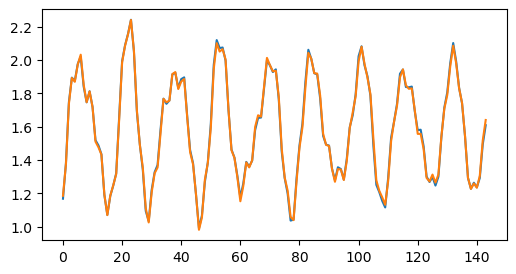

In [13]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

In [14]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient uncertainty >>>
	epoch 1 losses: train=-0.625431, valid=-1.155653, test=-1.139985
	validation loss decreased (inf -> -1.155653), saving model ...
	epoch 2 losses: train=-1.527556, valid=-1.222707, test=-1.216274
	validation loss decreased (-1.155653 -> -1.222707), saving model ...
	epoch 3 losses: train=-1.610707, valid=-1.211010, test=-1.168974
	early stopping counter: 1 out of 10
	epoch 4 losses: train=-1.656575, valid=-1.279842, test=-1.254128
	validation loss decreased (-1.222707 -> -1.279842), saving model ...
	epoch 5 losses: train=-1.679312, valid=-1.324142, test=-1.293929
	validation loss decreased (-1.279842 -> -1.324142), saving model ...
	epoch 6 losses: train=-1.703236, valid=-1.328541, test=-1.284497
	validation loss decreased (-1.324142 -> -1.328541), saving model ...
	epoch 7 losses: train=-1.722395, valid=-1.323063, test=-1.259955
	early stopping counter: 1 out of 10
	epoch 8 losses: train=-1.731036, valid=-1.351201, test=-1.310862
	validation loss d

In [15]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

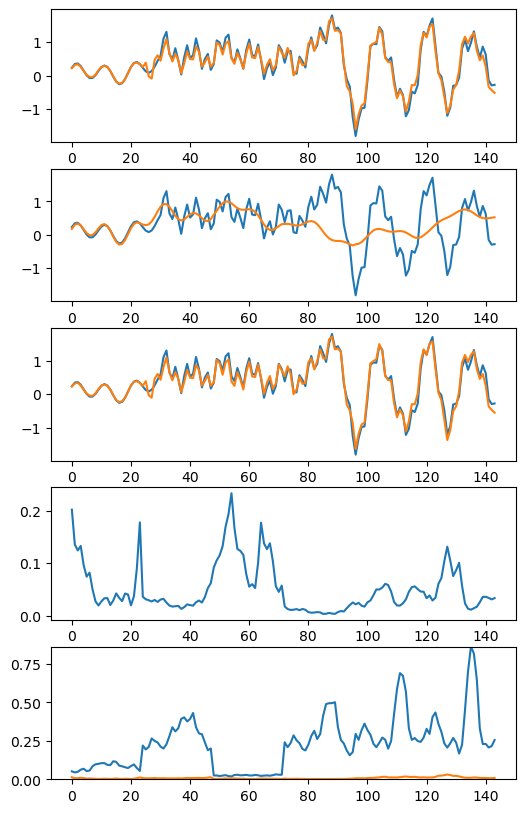

In [23]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break